In [1]:
import logging
# Let's disable all the annoying messages from PySME
logging.disable(logging.WARNING)
import warnings
warnings.filterwarnings(action="ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", module="pysme.synthesize")
# from astropy.utils.exceptions import AstropyWarning
# warnings.filterwarnings(action="ignore", category=AstropyWarning)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
np.set_printoptions(suppress=True, precision=6)
from astropy.io import fits

In [2]:
%load_ext autoreload
%autoreload 2
from pysme_wrapper import *
from pysme_wrapper.utils import *

/home/paramre/miniforge3/envs/sme/lib/python3.12/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/home/paramre/miniforge3/envs/sme/lib/python3.12/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [3]:
class FEROSspec:
    def __init__(self, filepath):
        with fits.open(filepath) as hdul:
            self.header = hdul[0].header
            self.wave_echelle = hdul[1].data
            self.wavelength = hdul[12].data
            self.flux = hdul[15].data
            self.getR = self.create_global_R_interpolant()

    def create_global_R_interpolant(self):  
        from scipy.interpolate import interp1d
        gridres=0.03
        waveord = self.wave_echelle
        # Create a fine grid spanning the global wavelength range.
        wave_grid = np.arange(waveord.min(), waveord.max()+gridres, gridres)
        Rgrid = np.zeros([len(waveord),len(wave_grid)])
        
        # Evaluate R at each grid point from each order
        for i, wave in enumerate(waveord):
            # Create interpolator; points outside the range return NaN.
            R = np.zeros(len(wave)); R[1:] = wave[1:]/(np.diff(wave)*2.2); R[0] = R[1]
            Rgrid[i] = np.interp(wave_grid, wave, R, left=np.nan, right=np.nan)
        
        #  Combine them    
        Ngp = np.isfinite(Rgrid).sum(0)
        c1 = Ngp==1
        c2 = Ngp==2
        c3 = Ngp>2
        Rcomb = np.zeros(len(wave_grid))
        Rcomb[c1|c3] = np.nanmedian(Rgrid[:,c1|c3], axis=0)
        Rcomb[c2] = np.nanmin(Rgrid[:,c2], axis=0)
        
        # Create a global interpolant object from the computed grid.
        global_R_interpolant = interp1d(wave_grid, Rcomb, kind='linear', bounds_error=True)
        return global_R_interpolant  

In [4]:
# load example spectrum
spec = FEROSspec('tauCeti_FEROS_spectrum_20250118.fits')
# some cleanup
spec.flux[(spec.wavelength<4500)&(spec.flux>1.05)] = np.nan
spec.flux[(spec.wavelength>4500)&(spec.flux>1.02)] = np.nan

In [5]:
balines = np.array([4554.03, 5853.68, 6496.9]) 
rv = 63.7

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(spec.wavelength, spec.flux)
plt.axhline(1.02, color='k', ls=':')
plt.axhline(1.05, color='k', ls=':')
plt.tight_layout()

for line in balines:
    plt.axvline(line*(1+rv/3e5), color='k')

In [25]:
sme = SMEwrapper()
sme.input_observed_spectrum(wave=spec.wavelength, flux=spec.flux, res=spec.getR(spec.wavelength)) 

# Fixed parameters
sme.logg = 4.48
sme.teff = 5328
sme.monh = -0.54
sme.vmac = 4.37
sme.vsini = 0.17
sme.vmic = calc_galah_vmic(sme.teff, sme.logg)

# # No point in any telluric correction - it's way overestimated anyway
# lat = spec.header['ESO TEL GEOLAT']
# alt = spec.header['ESO TEL GEOELEV']
# temp = spec.header['ESO TEL AMBI TEMP']
# press = (spec.header['ESO TEL AMBI pres start'] + spec.header['ESO TEL AMBI pres end'])/2
# hum = spec.header['ESO TEL AMBI RHUM']
# airmass = spec.header['AIRMASS']
# sme.get_telluric_transmission(lat=lat, alt=alt, temperature=temp, pressure=press, humidity=hum, airmass=airmass, resolution=48000, inair=True, nan_thresh=0.99)

In [26]:
sme.WRAN = create_ranges(balines[[0]], halfspan=0.3, join=True)
print(f'No of segments: {sme.NSEG}')

No of segments: 1


In [27]:
sme.WRAN

array([[4553.73, 4554.33]])

##### See how error and cscale fitting become useless at such a high SNR as ccont and cerr pick up observed lines that aren't in the synthesized spectrum.

In [ ]:
RV = sme.RV = sme.fit_RV()

In [ ]:
ERR, CS, debugdict = sme.get_error_and_cscale(debug_mode=True, continuum_threshold=0.98, smoothing_lambda=100)

In [ ]:
ERR

In [ ]:
for i in range(sme.NSEG):
    plt.figure(figsize=(10,3))
    plt.plot(debugdict['WAVE'][i], debugdict['FLUX'][i], 'C0-')
    ccont = debugdict['CCONT'][i]
    plt.plot(debugdict['WAVE'][i][ccont], debugdict['FLUX'][i][ccont], 'C1.')
    plt.plot(debugdict['WAVE'][i], CS[i](debugdict['WAVE'][i]), 'k-')
    plt.axvline(balines[i], color='k', ls=':')

In [ ]:
for i in range(sme.NSEG):
    plt.figure(figsize=(10,3))
    plt.plot(debugdict['WAVE'][i], debugdict['FLUX'][i], 'C0-')
    cerr = debugdict['CERR'][i]
    plt.plot(debugdict['WAVE'][i][cerr], debugdict['FLUX'][i][cerr], 'C1.')
    plt.plot(debugdict['WAVE'][i][cerr], debugdict['SYN'][i][cerr], 'C2.')
    plt.axvline(balines[i], color='k', ls=':')

##### So Set CS and ERR to None (or 1)

In [28]:
sme.make_fit_segments(RV='fit',CS=None,ERR=None,make_quality_cuts=False)
sme.nlte.set_nlte('Ba')

In [46]:
mcobj = MCMCsetup(sme, grids={'abund Ba':np.arange(0, 4.01, 0.1), 'vmic':np.arange(0,2,0.2)}, vsini_grid=[0,5], nprocesses=8)

No synthesized grid found in supplied grids. Creating synthesized grid...


Synthesizing grid:   0%|          | 0/410 [00:00<?, ?it/s]

In [47]:
%matplotlib widget

In [ ]:
from brokenaxes import brokenaxes

plt.figure(figsize=(10, 6))
baxes = brokenaxes(
    xlims=[(w.min(), w.max()) for w in mcobj.wavegrid],
    hspace=0.5
)

x = np.hstack(mcobj.wavegrid)
for syn in mcobj.syngrid:
    baxes.plot(x, syn, 'k-', alpha=0.2)

baxes.plot(np.hstack(sme.WAVE), np.hstack(sme.FLUX), color='C0')
plt.show()

In [50]:
sampler = mcobj.run_mcmc(nsteps=1500)

100%|██████████| 1500/1500 [00:15<00:00, 95.45it/s] 


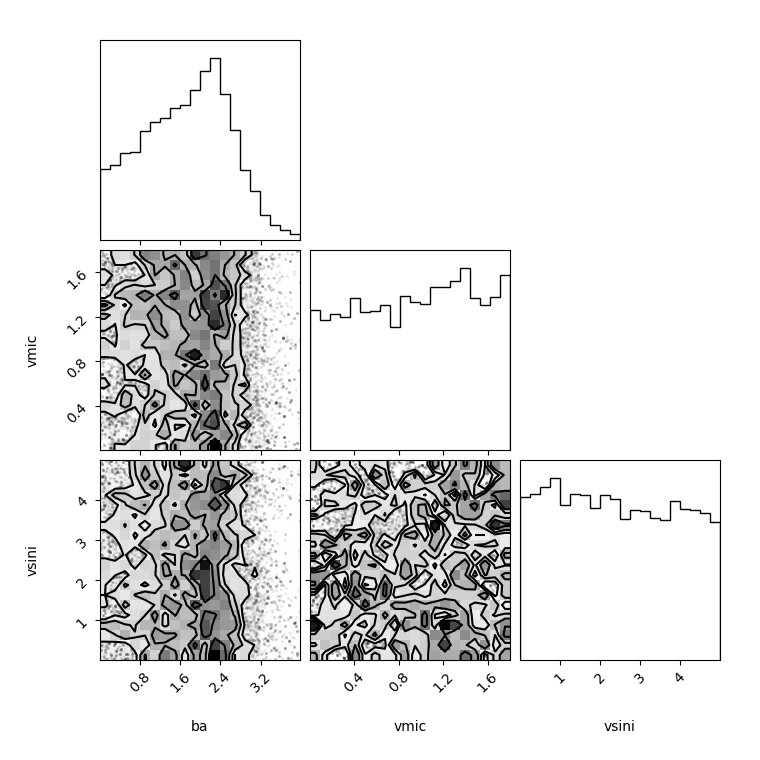

In [51]:
samples = sampler.get_chain(discard=500, thin=1, flat=True).squeeze()
# plt.figure()
# plt.hist(samples)
import corner
labels = ['ba', 'vmic', 'vsini']
corner.corner(samples, labels=labels)
plt.show()